In [35]:
#Importing pandas library which will be used for loading the dataset, Data Analysis, and Data Manipulation
import pandas as pd

#Imported warnings to ignore certain warnings that might arise
import warnings
warnings.filterwarnings('ignore')

#Loading the dataset
df = pd.read_csv("Crop_Data.csv")
df = df[~df.index.duplicated(keep = 'first')]
df.drop(columns=["ID"], axis=1, inplace=True)

Text(0.5, 1.0, 'Corelation Matrix')

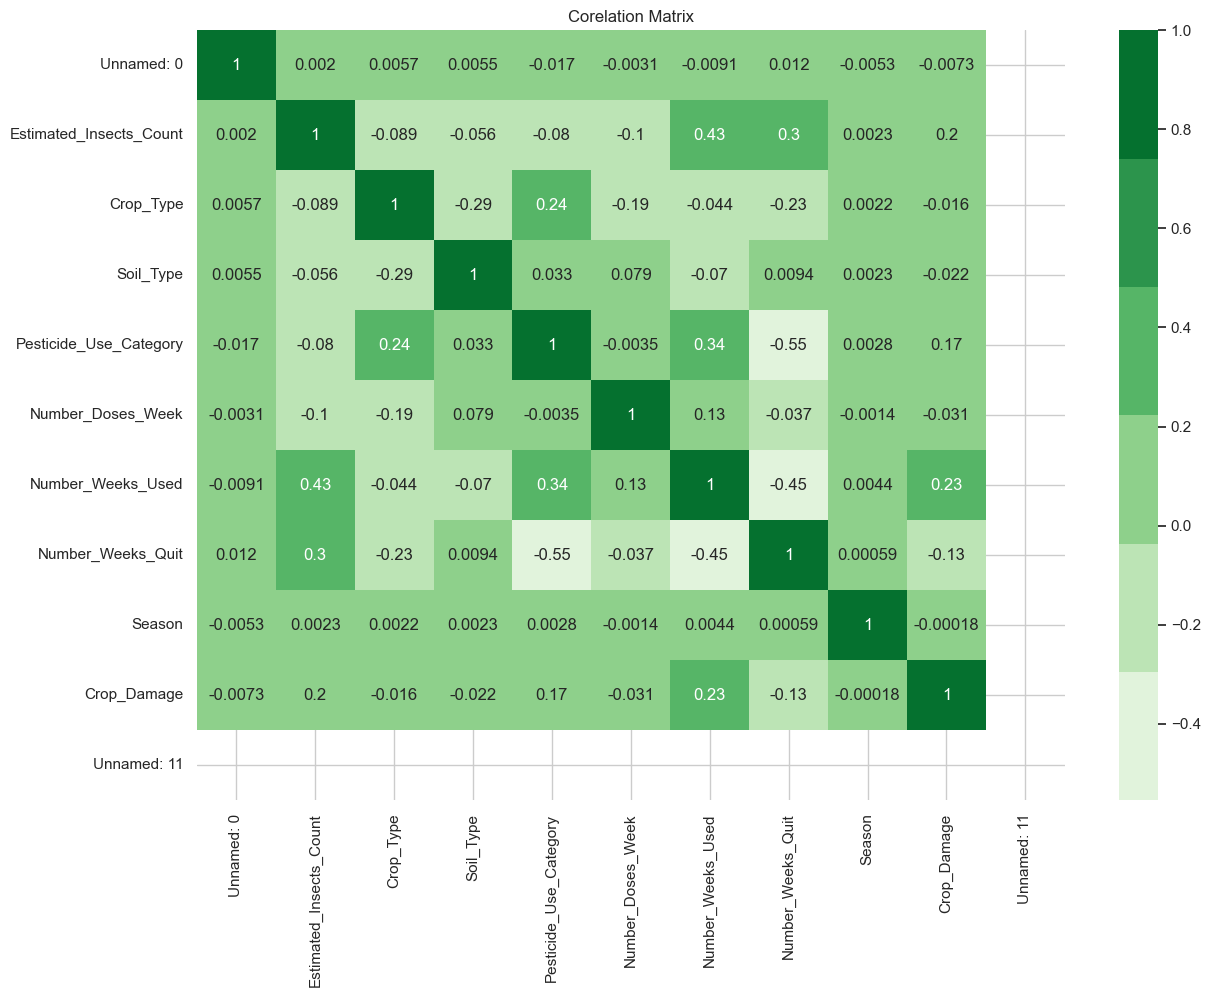

In [36]:
import matplotlib.pyplot as plt 
import seaborn as sns

df = df.apply(pd.to_numeric, errors='coerce')
plt.figure(figsize = (14,10))

colormap = sns.color_palette("Greens")

sns.heatmap(df.corr(), annot = True, cmap = colormap, cbar = True)

plt.title('Corelation Matrix')

1.Estimated_Insects_count,Pesticide_use_category and Number_weeks_used are positively correlated with Crop damage.

2.Number_weeks_used  is positively correlated with Estimated_Insects_count and Pesticide_use_category. 

3.Number_weeks_Quit is highly negatively correlated with Pesticide_use_category and Number_weeks_used.

## 2. Data Visualization

More Crops are alive than dead

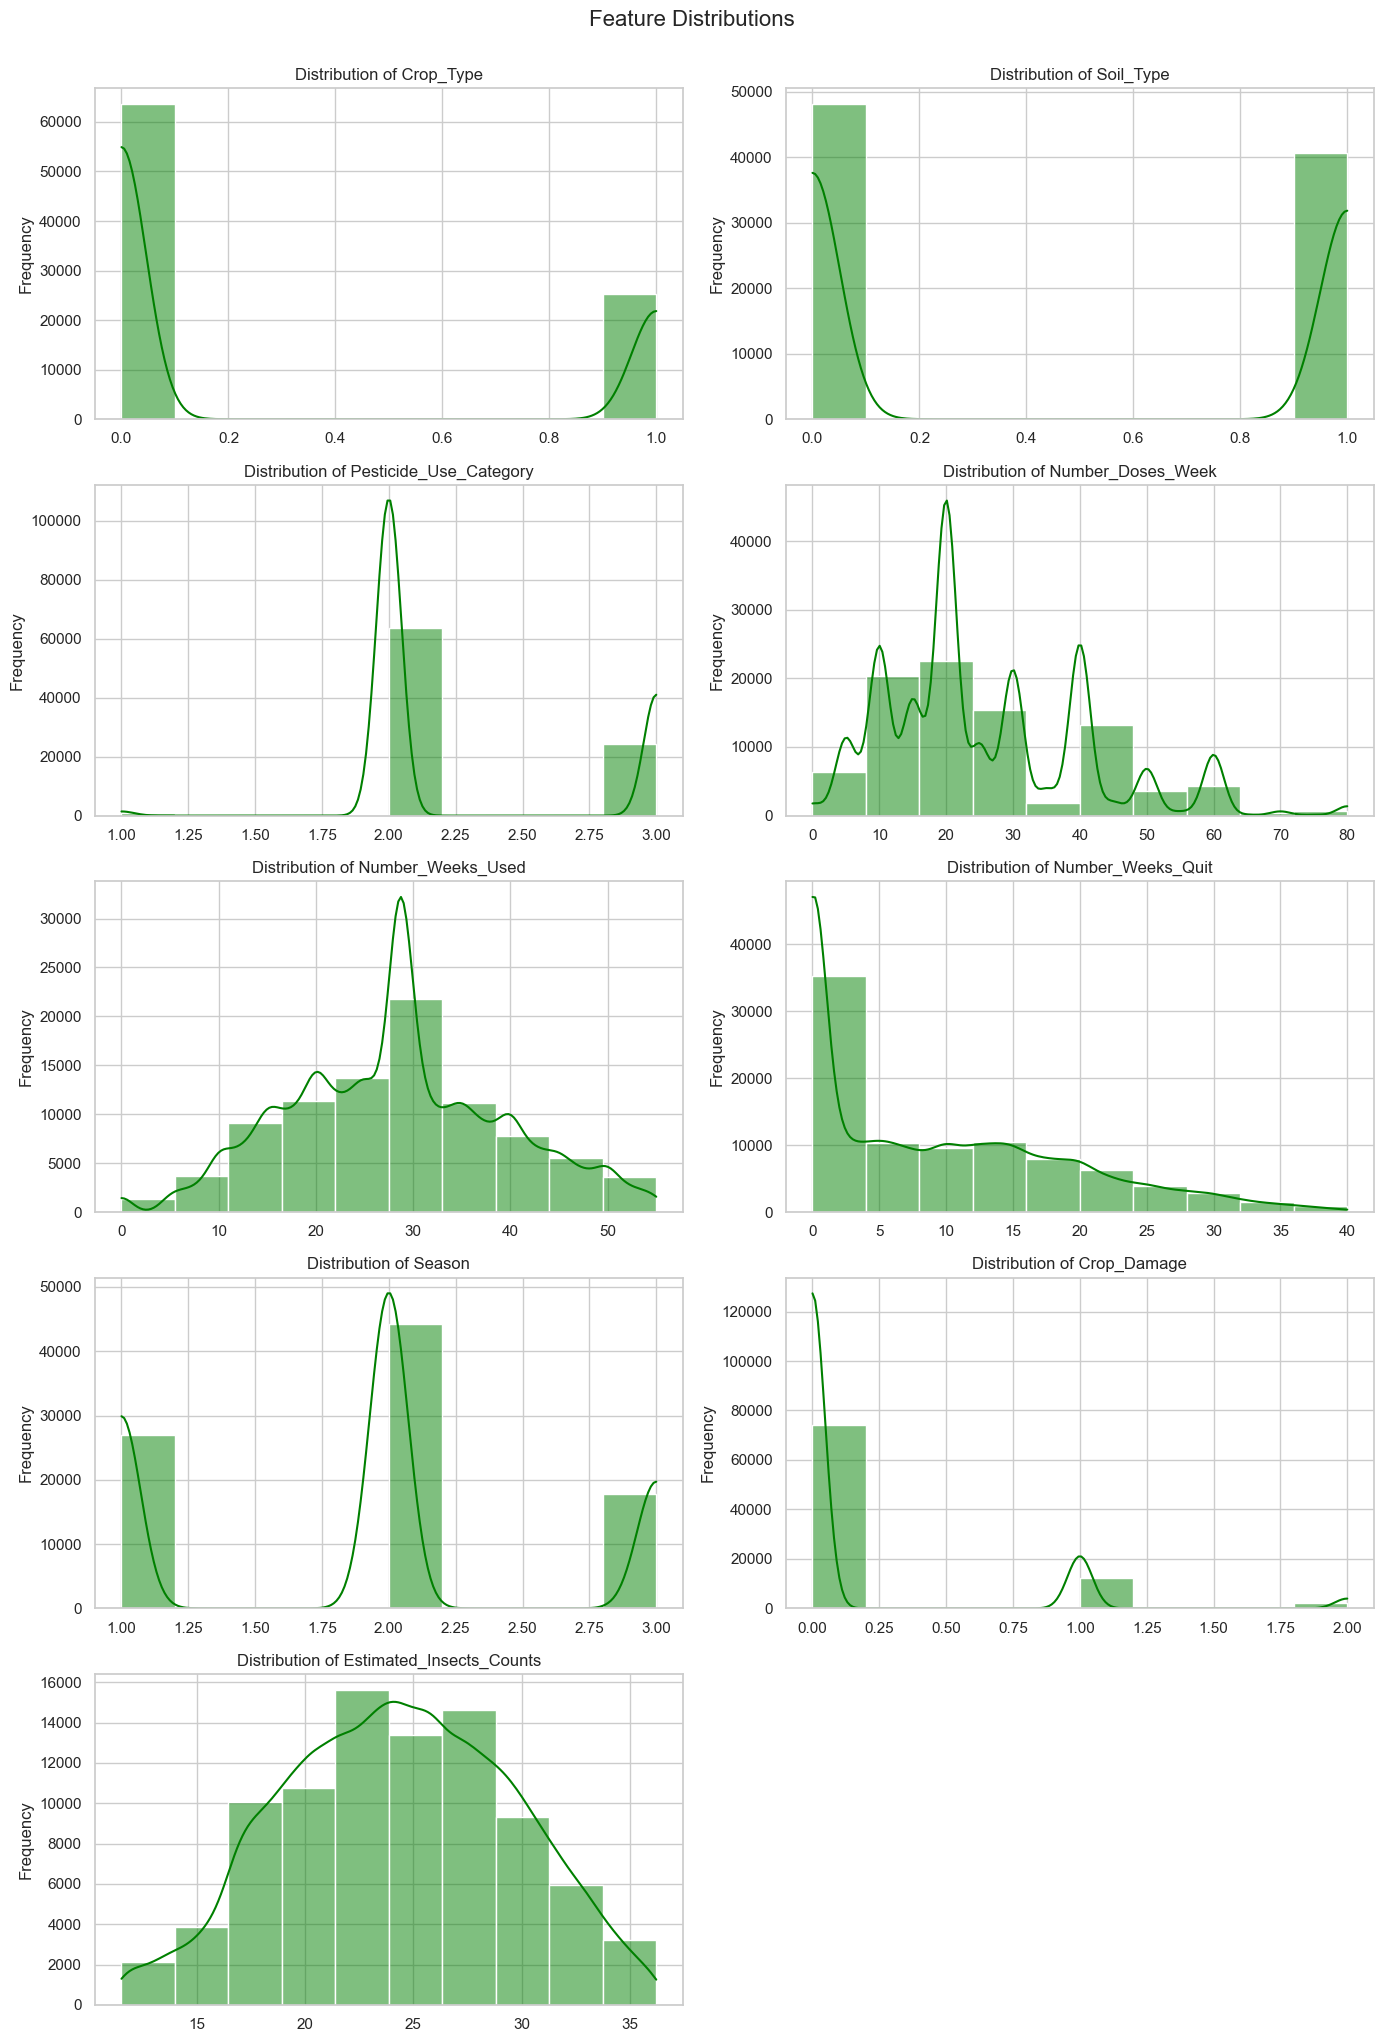

In [68]:
# #Histogram of all the features
# cols_to_plot = [col for col in df.columns if not col.startswith('Unnamed')]
# df[cols_to_plot].hist(figsize=(15, 20), layout=(6, 2), bins=10, color='green')

import matplotlib.pyplot as plt
import seaborn as sns

# Optional: use seaborn style for cleaner plots
sns.set(style="whitegrid")

# Select relevant columns (excluding unnamed)
cols_to_plot = [col for col in df.columns if not col.startswith('Unnamed')]

# Define layout based on number of columns
n_cols = 2
n_rows = (len(cols_to_plot) + 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], bins=10, color='green', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Remove unused subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.savefig("datadis.png", dpi=300, bbox_inches='tight')
plt.show()


1. Crop damage due to pesticides is very low. So, pesticides is recommended
2. Crop Type 0 will survive more than crop type 1
3. Soil Type is same as for 0 and 1(in the amounts)
4. Pesticide Category 2 is used more than 1 and 3 combined
5. 500 - 1000 sq meter has the highest insects count
6. Number_Weeks_Quit is positive skewed
7. Number_Weeks_Used is approximately normally distributed
8. Estimated Insects Count is right skewed

## 3. Data Cleaning and Feature Engineering

In [38]:
#Replacing missing values with the mean
df['Number_Weeks_Used'].fillna(df['Number_Weeks_Used'].mean(),inplace = True)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88858 entries, 0 to 88857
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               88858 non-null  int64  
 1   Estimated_Insects_Count  88858 non-null  int64  
 2   Crop_Type                88858 non-null  int64  
 3   Soil_Type                88858 non-null  int64  
 4   Pesticide_Use_Category   88858 non-null  int64  
 5   Number_Doses_Week        88858 non-null  int64  
 6   Number_Weeks_Used        88858 non-null  float64
 7   Number_Weeks_Quit        88858 non-null  int64  
 8   Season                   88858 non-null  int64  
 9   Crop_Damage              88858 non-null  int64  
 10  Unnamed: 11              0 non-null      float64
dtypes: float64(2), int64(9)
memory usage: 7.5 MB


**All the missing values are removed**

In [40]:
df.drop(columns=["Unnamed: 0", "Unnamed: 11"], axis=1, inplace=True, errors='ignore')
df.head(10)

,Estimated_Insects_Count,Crop_Type,Soil_Type,Pesticide_Use_Category,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Season,Crop_Damage
0,188,1,0,1,0,0.00000,0,1,0
1,209,1,0,1,0,0.00000,0,2,1
2,257,1,0,1,0,0.00000,0,2,1
3,257,1,1,1,0,0.00000,0,2,1
4,342,1,0,1,0,0.00000,0,2,1
5,448,0,1,1,0,28.62397,0,2,1
6,448,0,1,1,0,28.62397,0,2,1
7,577,1,0,1,0,0.00000,0,1,2
8,731,0,0,1,0,0.00000,0,2,0
9,1132,1,0,1,0,0.00000,0,1,2


Making features normally distrubuted

In [41]:
#Checking the skew of each feature
df.skew()

Estimated_Insects_Count    0.839146
Crop_Type                  0.955978
Soil_Type                  0.166914
Pesticide_Use_Category     0.779488
Number_Doses_Week          0.962879
Number_Weeks_Used          0.258007
Number_Weeks_Quit          0.892773
Season                     0.145228
Crop_Damage                2.367948
dtype: float64

As of now, Soil_Type, Number_Weeks_Used, Season are normally distributed

In [ ]:
#Function to return plots for the feature
import scipy.stats as stats
import pylab

def normality(data,feature):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    sns.kdeplot(data[feature])
    plt.subplot(1,2,2)
    stats.probplot(data[feature],plot=pylab)
    plt.show()

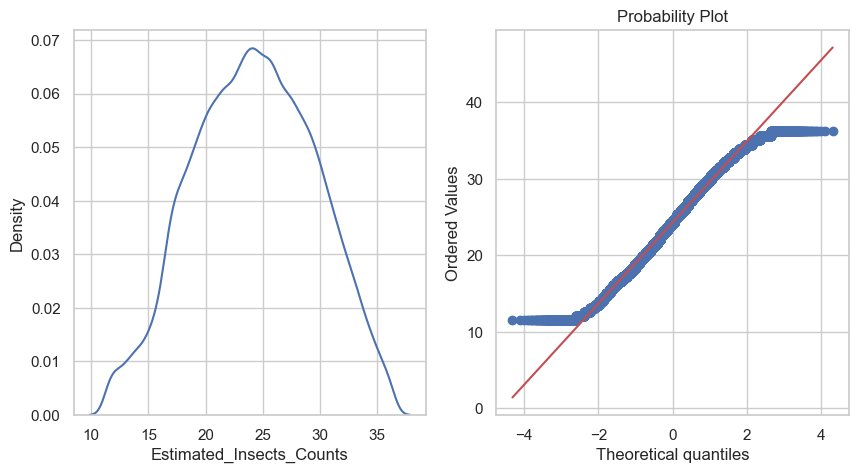

In [43]:
#Converting Estimated Insects Count feature to Normal Distribution using Box-Cox transform
#Plotting to check the transformation
import joblib
df['Estimated_Insects_Counts'], parameters = stats.boxcox(df['Estimated_Insects_Count'])
joblib.dump(parameters, 'boxcox_lambda.save')
normality(df,'Estimated_Insects_Counts')

In [44]:
df[df.index.duplicated()]

,Estimated_Insects_Count,Crop_Type,Soil_Type,Pesticide_Use_Category,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Season,Crop_Damage,Estimated_Insects_Counts


In [45]:
import numpy as np
df.loc[df['Number_Weeks_Used']>55,'Number_Weeks_Used'] = np.mean(df["Number_Weeks_Used"])

In [46]:
df.loc[df['Estimated_Insects_Count']>3500,'Estimated_Insects_Count'] = np.mean(df["Estimated_Insects_Count"])

In [47]:
df.loc[df['Number_Weeks_Quit']>40,'Number_Weeks_Quit'] = np.mean(df["Number_Weeks_Quit"])

In [48]:
df.loc[df['Number_Doses_Week']>80,'Number_Doses_Week'] = np.mean(df["Number_Doses_Week"])

In [49]:
df.drop(columns = ["Estimated_Insects_Count"], axis = 1, inplace = True)

## 4. Feature Scaling, Modelling and Evaluation

In [50]:
#Creating predictors and Target
y = df['Crop_Damage']
X = df.drop(columns = ['Crop_Damage'])

#Performing Train Test split using sklearn library
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 0)

In [51]:
#Verifying shapes of our test train split
print("X_train shape is ", X_train.shape)
print("X_test shape is ", X_test.shape)
print("y_train shape is ", y_train.shape)
print("y_test shape is ", y_test.shape)

X_train shape is  (71086, 8)
X_test shape is  (17772, 8)
y_train shape is  (71086,)
y_test shape is  (17772,)


In [52]:
# #We do encoding for nominal data so I used get_dummies method
# X_train = pd.get_dummies(data = X_train, columns = ["Season","Pesticide_Use_Category","Soil_Type","Crop_Type"])
# np.save('model_columns.npy', X_train.columns)
# X_train.head(10)

In [53]:
import joblib

#Let us normalize values for features(Number_Doses_Week,	Number_Weeks_Used,	Number_Weeks_Quit,	Estimated_Insects_Counts)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

joblib.dump(scaler, 'scaler.save')

['scaler.save']

In [54]:
# #Checking normalized values by creating a dataframe
# from pandas import DataFrame
# X_train_df = DataFrame(X_train)
# X_train_df.head(10)

In [55]:
# #Performed feature encoding to the X_test feature using get_dummies and then transformed
# X_test = pd.get_dummies(data = X_test, columns=["Season","Pesticide_Use_Category","Soil_Type","Crop_Type"])
# X_test = scaler.transform(X_test)

In [56]:
# #Creating a dataframe from normalized values of test dataset
# X_test_df = DataFrame(X_test)
# X_test_df.head(10)

## 4.2.Artificial Neural Network

In [57]:
# #Train Test Split
# X_train_net, X_test_net, y_train_net, y_test_net = train_test_split(X, y, train_size=0.8, random_state = 0)

In [58]:
# #Verifying shapes of our test train split
# print("X_train_net shape is ", X_train_net.shape)
# print("X_test_net shape is ", X_test_net.shape)
# print("y_train_net shape is ", y_train_net.shape)
# print("y_test_net shape is ", y_test_net.shape)

In [59]:
# #We do encoding for nominal data so I used get_dummies method
# X_train_net = pd.get_dummies(data = X_train_net, columns = ["Season","Pesticide_Use_Category","Soil_Type","Crop_Type"])
# X_train_net.head(10)

In [60]:
# #Importing libraries for Neural Nets
# from keras.models import Sequential
# from keras.layers import Dense
# from keras.layers import Input, Embedding, Flatten, Dense, Concatenate
# from keras.models import Model
# import tensorflow as tf

In [61]:
# from sklearn.preprocessing import StandardScaler
# from keras.regularizers import l2
# from keras.layers import Dropout
# from keras.callbacks import EarlyStopping
# from sklearn.utils import class_weight

# # Preprocess X_train_net
# scaler = StandardScaler()
# X_train_net_scaled = scaler.fit_transform(X_train_net)
# X_test_net_scaled = scaler.transform(X_test_net)

# # Convert target to numpy array
# y_train_net = np.array(y_train_net).astype(int)
# y_test_net = np.array(y_test_net).astype(int)

# # Compute class weights
# class_weights = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train_net),
#     y=y_train_net
# )
# class_weights_dict = dict(zip(np.unique(y_train_net), class_weights))

# # Modified model architecture
# model = Sequential([
#     Dense(64, input_dim=X_train_net.shape[1], activation='relu', kernel_regularizer=l2(0.01)),
#     Dropout(0.4),
#     Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
#     Dropout(0.4),
#     Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
#     Dense(3, activation='softmax')
# ])

# model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# # Training with modified parameters
# history = model.fit(
#     X_train_net_scaled,
#     y_train_net,
#     epochs=100,
#     batch_size=32,
#     validation_split=0.2,
#     class_weight=class_weights_dict,
#     callbacks=[
#         EarlyStopping(
#             monitor='val_loss',
#             patience=10,
#             restore_best_weights=True
#         )
#     ],
#     verbose=1
# )

# # Evaluate and predict using scaled data
# _, accuracy = model.evaluate(X_test_net_scaled, y_test_net)
# print('Test accuracy: %.2f' % (accuracy*100))

# predictions = model.predict(X_test_net_scaled)
# predicted_classes = np.argmax(predictions, axis=1)

In [62]:
# #Evaluate the keras model
# _, accuracy = model.evaluate(X_test, y_test)
# print('Accuracy: %.2f' % (accuracy*100))

In [63]:
# #Make probability predictions with the model
# predictions = model.predict(X_test)
# predicted_classes = np.argmax(predictions, axis=1)
# print(predicted_classes)

In [64]:
# #check model performance
# from sklearn.metrics import classification_report, confusion_matrix

# print(confusion_matrix(y_test, predicted_classes))
# print(classification_report(y_test, predicted_classes))


--- Baseline (No Resampling / Class Weight) ---
Accuracy: 0.8273
Weighted F1-score: 0.8020
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     14848
           1       0.41      0.24      0.30      2461
           2       0.14      0.04      0.06       463

    accuracy                           0.83     17772
   macro avg       0.47      0.41      0.42     17772
weighted avg       0.79      0.83      0.80     17772

Confusion Matrix:
 [[14100   696    52]
 [ 1812   584    65]
 [  286   158    19]]


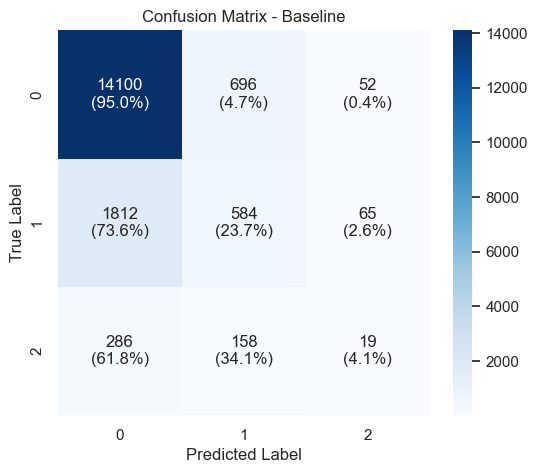


--- SMOTE ---
Accuracy: 0.8170
Weighted F1-score: 0.8010
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91     14848
           1       0.38      0.24      0.30      2461
           2       0.14      0.13      0.14       463

    accuracy                           0.82     17772
   macro avg       0.47      0.44      0.45     17772
weighted avg       0.79      0.82      0.80     17772

Confusion Matrix:
 [[13858   825   165]
 [ 1663   601   197]
 [  252   151    60]]


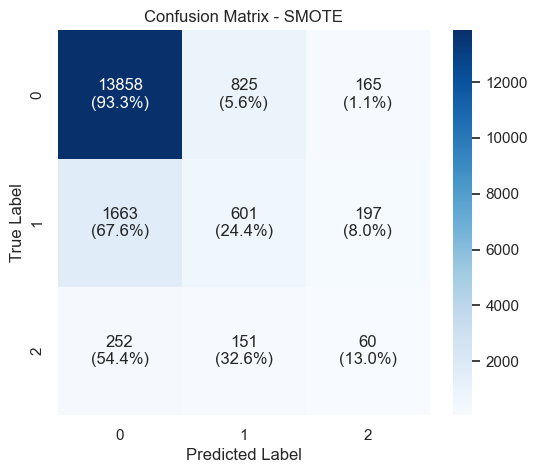


--- ADASYN ---
Accuracy: 0.8165
Weighted F1-score: 0.8004
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91     14848
           1       0.38      0.24      0.29      2461
           2       0.15      0.14      0.15       463

    accuracy                           0.82     17772
   macro avg       0.47      0.44      0.45     17772
weighted avg       0.79      0.82      0.80     17772

Confusion Matrix:
 [[13860   810   178]
 [ 1676   584   201]
 [  240   156    67]]


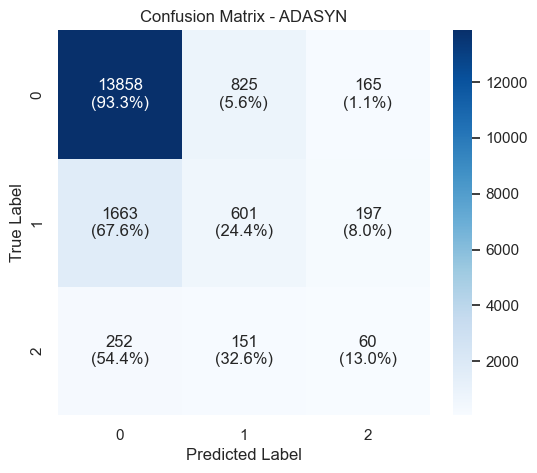


--- Class Weights ---
Accuracy: 0.7592
Weighted F1-score: 0.7747
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.84      0.87     14848
           1       0.29      0.38      0.33      2461
           2       0.11      0.17      0.13       463

    accuracy                           0.76     17772
   macro avg       0.43      0.46      0.44     17772
weighted avg       0.79      0.76      0.77     17772

Confusion Matrix:
 [[12483  2034   331]
 [ 1256   933   272]
 [  164   222    77]]


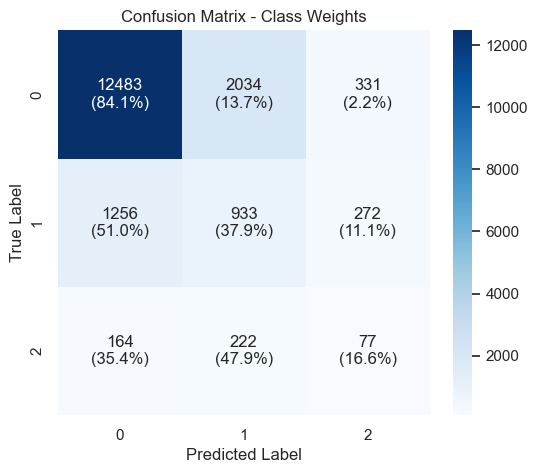

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import xgboost as xgb
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import ADASYN, SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0, stratify=y)

# One-hot encode categorical features
X_train = pd.get_dummies(X_train, columns=["Season", "Pesticide_Use_Category", "Soil_Type", "Crop_Type"])
X_test = pd.get_dummies(X_test, columns=["Season", "Pesticide_Use_Category", "Soil_Type", "Crop_Type"])
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(zip(np.unique(y_train), class_weights))
sample_weights = np.array([weight_dict[y] for y in y_train])

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row (true class)
    
    labels = np.array([["{0}\n({1:.1%})".format(c, p) for c, p in zip(row, row_norm)] 
                       for row, row_norm in zip(cm, cm_norm)])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=labels, fmt='', cmap="Blues", xticklabels=[0,1,2], yticklabels=[0,1,2])
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Base model config
def get_model():
    return xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        learning_rate=0.1,
        n_estimators=300,
        max_depth=15,
        min_child_weight=5,
        gamma=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=None,
        random_state=42,
        eval_metric='mlogloss'
    )

# Evaluation function
def evaluate(model_name, y_true, y_pred):
    print(f"\n--- {model_name} ---")
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1-score: {f1:.4f}")
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    
# 0. Baseline - No resampling or class weighting
model_baseline = get_model()
model_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = model_baseline.predict(X_test_scaled)
evaluate("Baseline (No Resampling / Class Weight)", y_test, y_pred_baseline)
plot_conf_matrix(y_test, y_pred_baseline, "Baseline")

# 1. Using SMOTE
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train_scaled, y_train)
model_smote = get_model()
model_smote.fit(X_resampled_smote, y_resampled_smote)
y_pred_smote = model_smote.predict(X_test_scaled)
evaluate("SMOTE", y_test, y_pred_smote)
plot_conf_matrix(y_test, y_pred_smote, "SMOTE")

# 2. Using ADASYN
adasyn = ADASYN(random_state=42)
X_resampled_adasyn, y_resampled_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
model_adasyn = get_model()
model_adasyn.fit(X_resampled_adasyn, y_resampled_adasyn)
y_pred_adasyn = model_adasyn.predict(X_test_scaled)
evaluate("ADASYN", y_test, y_pred_adasyn)
plot_conf_matrix(y_test, y_pred_smote, "ADASYN")

# 3. Using Class Weights
model_weights = get_model()
model_weights.fit(X_train_scaled, y_train, sample_weight=sample_weights)
y_pred_weights = model_weights.predict(X_test_scaled)
evaluate("Class Weights", y_test, y_pred_weights)
plot_conf_matrix(y_test, y_pred_weights, "Class Weights")


In [66]:
# #Train Test Split
# X_train_net, X_test_net, y_train_net, y_test_net = train_test_split(X, y, train_size=0.8, random_state = 0)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import ADASYN, SMOTE


# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0, stratify=y)

# One-hot encode categorical features
X_train = pd.get_dummies(X_train, columns=["Season", "Pesticide_Use_Category", "Soil_Type", "Crop_Type"])
X_test = pd.get_dummies(X_test, columns=["Season", "Pesticide_Use_Category", "Soil_Type", "Crop_Type"])

# Align columns to ensure they match
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

#  Normalize numerical features
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weight_dict = dict(zip(np.unique(y_train), class_weights))

# Build and train the XGBoost classifier
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    learning_rate=0.1,
    n_estimators=300,
    max_depth=15,
    min_child_weight=5,
    gamma = 0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=None,  
    random_state=42,
    eval_metric='mlogloss'
)
# Train with sample weights
sample_weights = np.array([weight_dict[y] for y in y_train])

#SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
model.fit(X_train_resampled, y_train_resampled)

#ADASYN
# adasyn = ADASYN(random_state=42)
# X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)
# model.fit(X_train_resampled, y_train_resampled)

# model.fit(X_train, y_train,sample_weight=sample_weights)

# Make predictions and evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Print sample predictions
print("Sample Predictions (first 10):")
print("True labels:", y_test[:10].values)
print("Predicted:", y_pred[:10])

print("\nPrediction Probabilities (first 10):")
for i in range(10):
    print(f"Sample {i+1}: Class 0: {y_proba[i][0]:.3f}, Class 1: {y_proba[i][1]:.3f}, Class 2: {y_proba[i][2]:.3f}")

# Print overall metrics
print("\nPrediction Distribution:")
unique, counts = np.unique(y_pred, return_counts=True)
pred_dist = dict(zip(unique, counts))
for class_label in sorted(pred_dist.keys()):
    print(f"Class {class_label}: {pred_dist[class_label]} predictions ({pred_dist[class_label]/len(y_pred)*100:.2f}%)")

print("\nOverall Metrics:")
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy: %.2f%%" % (accuracy * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Sample Predictions (first 10):
True labels: [1 0 1 0 0 0 0 0 1 0]
Predicted: [0 0 0 0 0 0 0 0 0 0]

Prediction Probabilities (first 10):
Sample 1: Class 0: 0.781, Class 1: 0.131, Class 2: 0.088
Sample 2: Class 0: 0.925, Class 1: 0.063, Class 2: 0.011
Sample 3: Class 0: 0.901, Class 1: 0.018, Class 2: 0.080
Sample 4: Class 0: 0.921, Class 1: 0.079, Class 2: 0.000
Sample 5: Class 0: 0.987, Class 1: 0.013, Class 2: 0.000
Sample 6: Class 0: 0.636, Class 1: 0.285, Class 2: 0.078
Sample 7: Class 0: 0.870, Class 1: 0.129, Class 2: 0.002
Sample 8: Class 0: 0.913, Class 1: 0.081, Class 2: 0.006
Sample 9: Class 0: 0.853, Class 1: 0.144, Class 2: 0.002
Sample 10: Class 0: 0.998, Class 1: 0.002, Class 2: 0.000

Prediction Distribution:
Class 0: 15773 predictions (88.75%)
Class 1: 1577 predictions (8.87%)
Class 2: 422 predictions (2.37%)

Overall Metrics:
XGBoost Accuracy: 81.70%

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0

In [67]:
# Save the XGBoost model
model.save_model("harvestcrop.json")

# To save both model and scaler for later use
import joblib
joblib.dump({
    'model': model,
    'scaler': scaler
}, 'harvest_model_complete.joblib')

['harvest_model_complete.joblib']